#### Decision Trees

In [156]:

# setup
from mlwpy import *
%matplotlib inline

iris = datasets.load_iris()

# standard iris dataset
tts = skms.train_test_split(iris.data, iris.target, 
                            test_size=.33, random_state=21)
(iris_train_ftrs, iris_test_ftrs, 
 iris_train_tgt,  iris_test_tgt) = tts

# one-class variation
useclass = 1
tts_1c = skms.train_test_split(iris.data, iris.target==useclass, 
                               test_size=.33, random_state = 21)
(iris_1c_train_ftrs, iris_1c_test_ftrs, 
 iris_1c_train_tgt,  iris_1c_test_tgt) = tts_1c

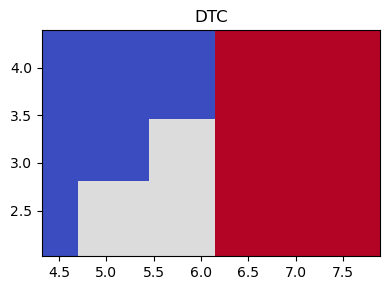

In [157]:
tree_classifiers = {'DTC': tree.DecisionTreeClassifier(max_depth = 3)}

fig , ax = plt.subplots(1,1,figsize=(4,3))
for name, mod in tree_classifiers.items():
    plot_boundary(ax,iris.data,iris.target,mod,[0,1])
    ax.set_title(name)

plt.tight_layout()

In [158]:
dtc = tree.DecisionTreeClassifier()
skms.cross_val_score(dtc, iris.data, iris.target, cv=3, scoring="accuracy")

array([0.98, 0.92, 0.98])

In [159]:
iris_1c_tree = (tree.DecisionTreeClassifier()).fit(iris_1c_train_ftrs, iris_1c_train_tgt)

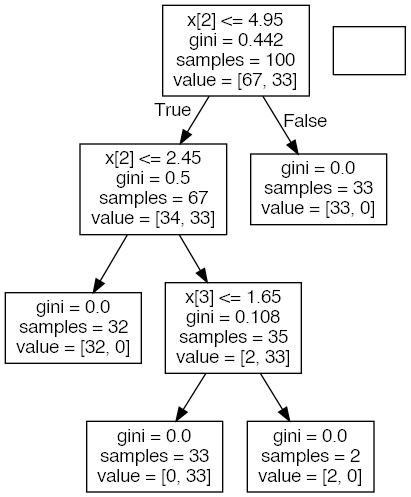

In [160]:
import pydotplus
dot_data = tree.export_graphviz(iris_1c_tree,out_file = None)
graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_png("outputs/iris_1c.png")
Image("outputs/iris_1c.png",width=100,height=100)


In [161]:
iris_tree = (tree.DecisionTreeClassifier().fit(iris_train_ftrs,iris_train_tgt))

'rm' is not recognized as an internal or external command,
operable program or batch file.


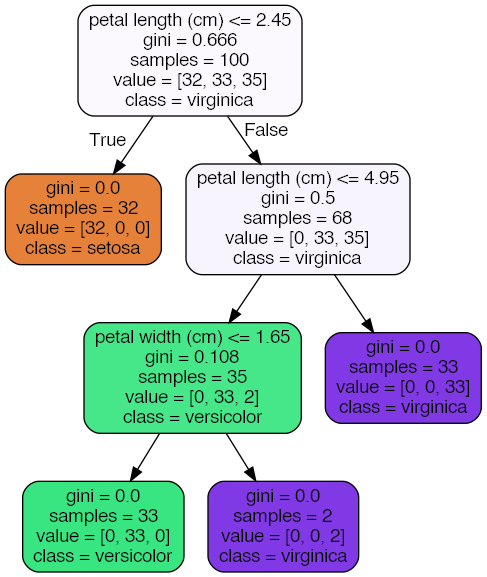

In [162]:
# no added lib. to produce .dot file
with open("outputs/iris.dot", 'w') as f:
    dot_data = tree.export_graphviz(iris_tree, out_file=f, 
                                    feature_names=iris.feature_names,  
                                    class_names=iris.target_names,  
                                    filled=True, rounded=True)

# the following '!' lines are "shell" commands
# uses the 'dot' program to convert to dot -> png
!dot -Tpng outputs/iris.dot -o outputs/iris.png
!rm outputs/iris.dot

Image("outputs/iris.png", width=140, height=140)

#### Support Vector Classifiers

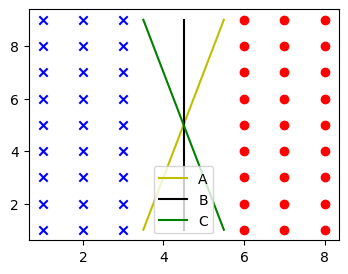

In [163]:
fig, ax = plt.subplots(1,1,figsize=(4,3))

# fancy way to get cross-product of points
left  = np.mgrid[1:4.0, 1:10].reshape(2, -1).T
right = np.mgrid[6:9.0, 1:10].reshape(2, -1).T

# data points
ax.scatter(left[:,0] , left[:,1] , c='b', marker='x')
ax.scatter(right[:,0], right[:,1], c='r', marker='o')

# separating lines
ax.plot([3.5, 5.5], [1,9], 'y', label='A')
ax.plot([4.5, 4.5], [1,9], 'k', label='B')
ax.plot([3.5, 5.5], [9,1], 'g', label='C')
ax.legend(loc='lower center');
     

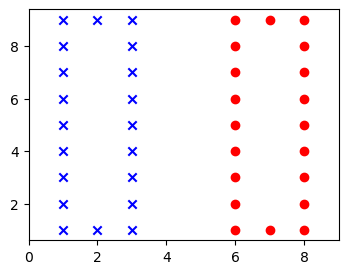

In [164]:
fig, ax = plt.subplots(1,1,figsize=(4,3))

# fancy way to get cross-product of points
left  = np.mgrid[1:4:2, 1:10].reshape(2, -1).T
right = np.mgrid[6:9:2, 1:10].reshape(2, -1).T

ax.scatter(left[:,0] , left[:,1] , c='b', marker='x')
ax.scatter([2,2], [1,9], c='b', marker='x')
ax.scatter(right[:,0], right[:,1], c='r', marker='o')
ax.scatter([7,7], [1,9], c='r', marker='o')
ax.set_xlim(0,9);
     

[[3 1]
 [3 2]
 [3 3]
 [3 4]
 [3 5]
 [3 6]
 [3 7]
 [3 8]
 [3 9]]


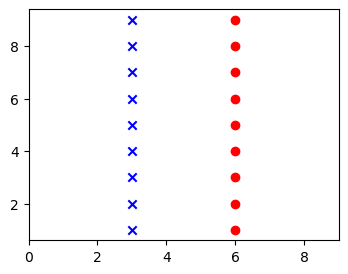

In [165]:
fig, ax = plt.subplots(1,1,figsize=(4,3))

left  = np.mgrid[3:4, 1:10].reshape(2, -1).T
right = np.mgrid[6:7, 1:10].reshape(2, -1).T
print(left)
ax.scatter(left[:,0] , left[:,1] , c='b', marker='x')
ax.scatter(right[:,0], right[:,1], c='r', marker='o')
ax.set_xlim(0,9);

In [166]:
sv_classifiers = {"SVC(Linear)":svm.SVC(kernel='linear'),
                 "NuSVC(linear)":svm.NuSVC(kernel='linear',nu=.9)}

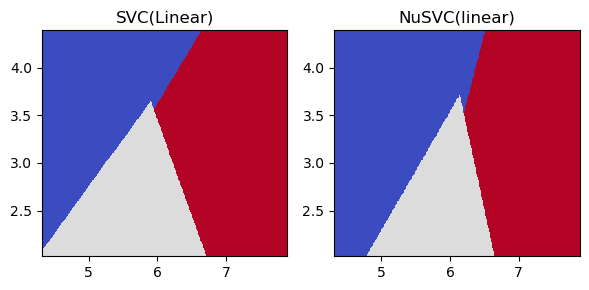

In [167]:
fig,axes = plt.subplots(1,2,figsize=(6,3))

for (mod_name,model),ax in zip(sv_classifiers.items(),axes.flat):
    plot_boundary(ax,iris.data,iris.target,model,[0,1])
    ax.set_title(mod_name)

plt.tight_layout()

In [168]:
def do_linear_svc_separators(svc_maker, pname, params, ax):
    'create svc(params) and draw seperation boundary'
    xys = (np.linspace(2,8,100),
           np.linspace(2,8,100))

    for p in params:
        kwargs = {pname:p, 'kernel':'linear'}
        svc = svc_maker(**kwargs).fit(ftrs, tgt)
        # plot_separator is in mlwpy.py
        plot_separator(svc, *xys, 
                       '{}={:g}'.format(pname, p), ax=ax)

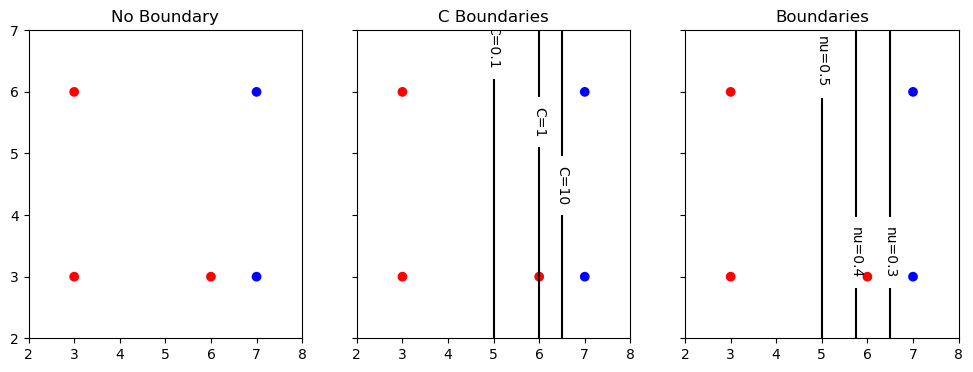

In [169]:
ftrs = np.array([[3,3],
                 [3,6],
                 [7,3],
                 [7,6],
                 [6,3]])
tgt  = np.array([0,0,1,1,0])
colors = np.array(['r', 'b'])

Cs = [.1, 1.0, 10]
nus = [.3, .4, .5]

fig, axes = plt.subplots(1,3,figsize=(12,4),
                         sharex=True, sharey=True)
for ax in axes:
    ax.scatter(ftrs[:,0], ftrs[:,1], c=colors[tgt])
ax.set_xlim(2,8); ax.set_ylim(2,7)

do_linear_svc_separators(svm.SVC,   "C",   Cs, axes[1])
do_linear_svc_separators(svm.NuSVC, "nu", nus, axes[2])

axes[0].set_title("No Boundary")
axes[1].set_title("C Boundaries")
axes[2].set_title("Boundaries");

(-4.048648111062722,
 2.2928982478347053,
 -2.8601040559667297,
 5.263696322840006)

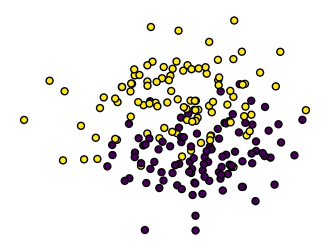

In [170]:
ftrs, tgt = datasets.make_blobs(centers=2,
                                n_features=3,
                                n_samples=200,
                                center_box = (-2.0, 2.0),
                                random_state=1099)

# note, using three features, but graphing only two dimensions
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.scatter(ftrs[:, 0], ftrs[:, 1], 
           marker='o', c=tgt, s=25, edgecolor='k')
ax.axis('off')

In [171]:
# adjusted to remove infeasible nu values
nus = np.linspace(0.05, .85, 9)
tt = skms.validation_curve(svm.NuSVC(kernel='linear'), 
                           ftrs, tgt, 
                           param_name='nu',
                           param_range=nus,
                           cv=5)

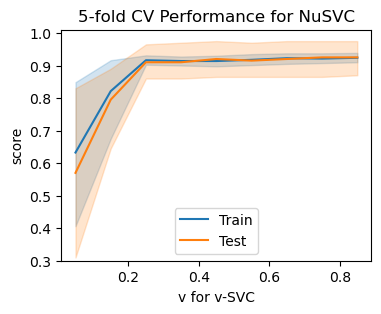

In [172]:
fig,ax = plt.subplots(1,1,figsize=(4,3))

tidy_df = sk_graph_to_tidy(tt, nus, 'nu', 5)
ax = sns.lineplot(x='nu', y='score', hue='set', data=tidy_df)

ax.set_title('5-fold CV Performance for NuSVC')
ax.set_xlabel("\n".join([r'v for v-SVC']))
ax.set_ylim(.3, 1.01)
ax.legend(loc='lower center');

In [173]:
cs = [0.0001, 0.001, 0.01, .1, 1.0, 10, 100, 1000]
tt = skms.validation_curve(svm.SVC(kernel='linear'), 
                           ftrs, tgt, 
                           param_name='C',
                           param_range=cs,
                           cv=5)
     

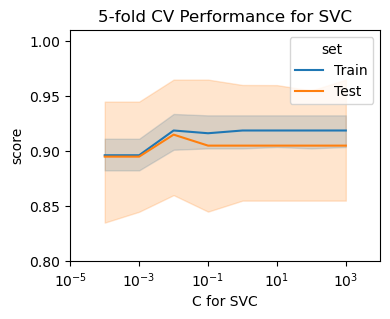

In [174]:
fig,ax = plt.subplots(1,1,figsize=(4,3))

tidy_df = sk_graph_to_tidy(tt, cs, 'c', 5)
ax = sns.lineplot(x='c',y='score',hue='set',data=tidy_df)

ax.set_title('5-fold CV Performance for SVC')
ax.set_xlabel("\n".join([r'C for SVC']))
ax.set_ylim(.8, 1.01)
ax.set_xlim(.00001, 10001)
ax.set_xscale('log')

#### Logistic Regression

In [175]:
def simple_argmax(arr):
    ' helper to convert np.argmax into something usable '
    return np.array(np.unravel_index(np.argmax(arr), 
                                     arr.shape))

def df_names(df, idxs):
    ' helper to convert number of index/column labels '
    r,c = idxs
    return df.index[r], df.columns[c]
     

In [176]:
base_bets = np.arange(1,12,2)
mark_bet,andy_bet = np.meshgrid(base_bets,base_bets)
mark_winnings = .1*andy_bet + .9* -mark_bet
df = pd.DataFrame(mark_winnings,index=base_bets,columns = base_bets)
df.index.name = 'andy winnings'
df.columns.name = 'mark winnings'
df
print("best best winning scenario for mark is:")
print("Andy , mark",df_names(df,simple_argmax(mark_winnings)))
display(df)

best best winning scenario for mark is:
Andy , mark (11, 1)


mark winnings,1,3,5,7,9,11
andy winnings,,,,,,
1,-0.8000,-2.6000,-4.4000,-6.2000,-8.0000,-9.8000
3,-0.6000,-2.4000,-4.2000,-6.0000,-7.8000,-9.6000
5,-0.4000,-2.2000,-4.0000,-5.8000,-7.6000,-9.4000
7,-0.2000,-2.0000,-3.8000,-5.6000,-7.4000,-9.2000
9,0.0000,-1.8000,-3.6000,-5.4000,-7.2000,-9.0000
11,0.2000,-1.6000,-3.4000,-5.2000,-7.0000,-8.8000


#### Probabilities, Odds and Log Odds

In [177]:
tail_probs = np.array([0.0,0.001,.01,.05,.10,.25,1.0/3.0])

lowr_probs = np.array(tail_probs)
upper_probs = 1 - lowr_probs[::-1]
cent_probs = np.array([.5])

probs = np.concatenate([lowr_probs,cent_probs,upper_probs])

with np.errstate(divide='ignore'):
    odds = probs/(1-probs)
    log_odds = np.log(odds)

index = ["{:4.1f}%".format(p) for p in np.round(probs,3)*100]

polo_dict = co.OrderedDict([(
    "Prob(E)", probs
),
    ("Odds(E:notE)", odds),
    ("Log Odds",log_odds)])

polo_df = pd.DataFrame(polo_dict,index=index)
polo_df.index.name="Pct(%)"
polo_df

,Prob(E),Odds(E:notE),Log Odds
Pct(%),,,
0.0%,0.0000,0.0000,-inf
0.1%,0.0010,0.0010,-6.9068
1.0%,0.0100,0.0101,-4.5951
5.0%,0.0500,0.0526,-2.9444
10.0%,0.1000,0.1111,-2.1972
25.0%,0.2500,0.3333,-1.0986
33.3%,0.3333,0.5000,-0.6931
50.0%,0.5000,1.0000,0.0000
66.7%,0.6667,2.0000,0.6931


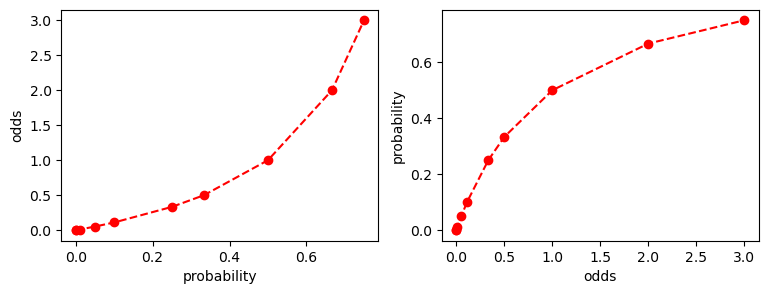

In [178]:
def helper(ax,x,y,x_name,y_name):
    ax.plot(x,y,'r--o')
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)

fig, (ax0,ax1) = plt.subplots(1,2,figsize=(9,3))
helper(ax0,probs[:-5],odds[:-5],'probability','odds')
helper(ax1,odds[:-5],probs[:-5],'odds','probability')


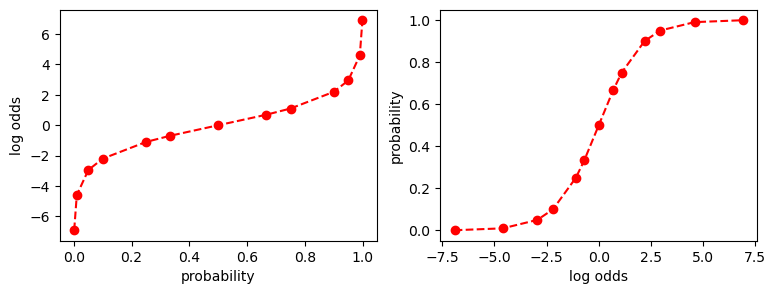

In [179]:
fig, (ax0,ax1) = plt.subplots(1,2,figsize=(9,3))
helper(ax0,probs,log_odds,'probability','log odds')
helper(ax1,log_odds,probs,'log odds','probability')

In [180]:

pd.DataFrame([polo_df.min(axis=0),
              polo_df.max(axis=0)], index=['min', 'max']).T

,min,max
Prob(E),0.0000,1.0000
Odds(E:notE),0.0000,inf
Log Odds,-inf,inf


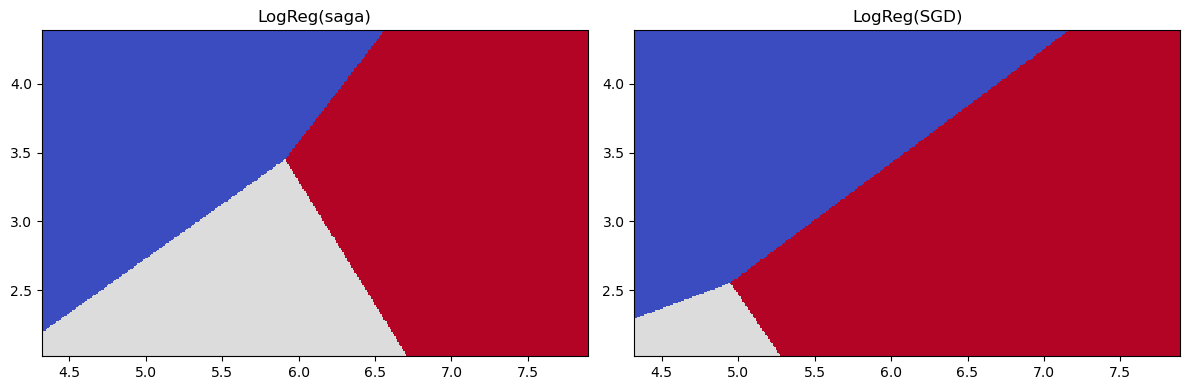

In [181]:
# Both options come with "regularization" turned ON, 
# we'll ignore that for now, but see Chapter 9 for more details
LogReg = linear_model.LogisticRegression
SGD    = linear_model.SGDClassifier
logreg_classifiers = {'LogReg(saga)': LogReg(solver='saga', 
                                             multi_class='multinomial',
                                             max_iter=1000),
                      'LogReg(SGD)' :  SGD(loss='log_loss', max_iter=1000)}

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes = axes.flat
for (name, mod), ax in zip(logreg_classifiers.items(), axes):
    plot_boundary(ax, iris.data, iris.target, mod, [0,1])
    ax.set_title(name)
plt.tight_layout()

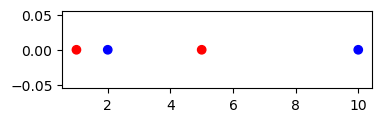

In [182]:
fig, ax = plt.subplots(1,1,figsize=(4,1))

x = np.array([1,2,5,10]).reshape(-1, 1)
y = ['red', 'blue', 'red', 'blue']
ax.scatter(x,np.zeros_like(x), c=y);

In [183]:
# note:  different import source
import statsmodels.api as sm

# x = np.c_[x, np.ones_like(x)] # +1 trick
# tgt = (np.array(y) == 'red')

# sm.Logit is statsmodels name for logistic regression
# Logit is very, very unhappy trying to deal with a perfectly 
#       separable example.  so, there are many weird arguments.
#       and it still seems to fail.
# FIXME.  I want just a simple example that recovers the target
#         function.
# (sm.Logit(tgt, x)
#   .fit(method='newton', skip_hessian=True, 
#        full_output=False, warn_convergence=False)
#   .predict(x))  # training predictions

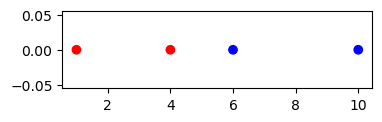

In [184]:

fig, ax = plt.subplots(1,1,figsize=(4,1))

x = np.array([1,4,6,10]).reshape(-1, 1)
y = ['red', 'red', 'blue', 'blue']
ax.scatter(x, np.zeros_like(x), c=y);

In [185]:

x = np.c_[x, np.ones_like(x)] # +1 trick
tgt = (np.array(y) == 'red')
try:
    (sm.Logit(tgt, x, method='newton')
       .fit()
       .predict(x)) # in-sample predictions
except Exception as e:
    print(e)

         Current function value: 0.000000
         Iterations: 35


C:\Users\Ritik\anaconda3\Lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['method']
  warnings.warn(msg, ValueWarning)
C:\Users\Ritik\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\Ritik\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\Ritik\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\Ritik\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfec

In [186]:
X = np.array([1,3,5,10,20])
n = len(X)

mean_X = sum(X) / n
errors = X - mean_X
var_X = np.dot(errors, errors) / n

fmt = "long way: {}\nbuilt in: {}\n   close: {}"
print(fmt.format(var_X, 
                 np.var(X), 
                 np.allclose(var_X, np.var(X)))) # phew

long way: 46.16
built in: 46.16
   close: True


In [187]:
X = np.array([1,3,5,10,20])
Y = np.array([2,4,1,-2,12])

mean_X = sum(X) / n
mean_Y = sum(Y) / n

errors_X = X - mean_X
errors_Y = Y - mean_Y

cov_XY = np.dot(errors_X, errors_Y) / n
print("long way: {:5.2f}".format(cov_XY))
print("built in:", np.cov(X,Y,bias=True)[0,1])
# note:
# np.cov(X,Y,bias=True) gives [Cov(X,X), Cov(X,Y)
#                              Cov(Y,X), Cov(Y,Y)]

long way: 21.28
built in: 21.28


In [188]:
var_x = 0
n = len(X)
for i in range(n):
    for j in range(i, n): # rest of Xs
        var_x += (X[i] - X[j])**2
print("Var(X):", var_x / n**2)

Var(X): 46.16


In [189]:
cov_xy = 0
for i in range(len(X)):
    for j in range(i, len(X)): # rest of Xs, Ys
        cov_xy += (X[i] - X[j])*(Y[i]-Y[j])
print("Cov(X,Y):", cov_xy / n**2)

Cov(X,Y): 21.28


In [190]:
cov_XY = 0.0
xy_pairs = it.product(zip(X,Y), repeat =2)
for (x_i,y_i),(x_j,y_j) in xy_pairs:
    cov_XY+=(x_i-x_j) * (y_i - y_j)

print("COV(X,Y):", cov_XY/(2 * n**2))

COV(X,Y): 21.28


In [191]:
cov_XX = 0.0
for x_i, x_j in it.combinations(X, 2):
    cov_XX += (x_i - x_j)**2
print("Cov(X,X) == Var(X):", cov_XX / (n**2))
     

Cov(X,X) == Var(X): 46.16


In [192]:
cov_XY = 0.0
for (x_i, y_i), (x_j,y_j) in it.combinations(zip(X,Y), 2):
    cov_XY += (x_i - x_j) * (y_i - y_j)
print("Cov(X,Y):", cov_XY / (n**2))

Cov(X,Y): 21.28


In [193]:
def sigmoid(x):
    return np.exp(-np.logaddexp(0,-x))

def draw_rectangle(arr,pt1,pt2):
    (x1,y1),(x2,y2) = pt1,pt2
    delta_x,delta_y = x2-x1,y2-y1
    r,c = min(y1,y2),min(x1,x2)

    arr[r:r+abs(delta_y), c:c+abs(delta_x)] += np.sign(delta_x * delta_y)

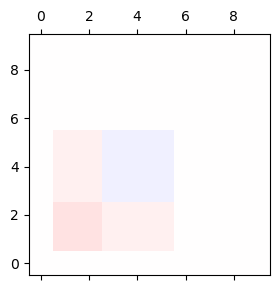

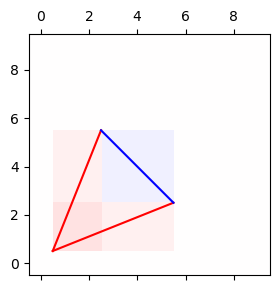

In [194]:
#now our data points
pts = [(1,1),(3,6),(6,3)]
pt_array = np.array(pts,dtype = np.float64)

#the array we are drawing upon
draw_arr = np.zeros((10,10))
ct = len(pts)
c_magic = 1 / ct**2

#we use the clever don't-double-count method
for pt1,pt2 in it.combinations(pts,2):
    draw_rectangle(draw_arr,pt1,pt2)
draw_arr *= c_magic

#display the array we drew
from matplotlib import cm
fig,ax = plt.subplots(1,1,figsize=(4,3))
ax.matshow(sigmoid(draw_arr),origin='lower',cmap=cm.bwr,vmin=0,vmax=1)
fig.tight_layout()

# display the array we drew
from matplotlib import cm
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.matshow(sigmoid(draw_arr), origin='lower', cmap=cm.bwr, vmin=0, vmax=1)
fig.tight_layout()

# show a diagonal across each rectangles
# the array elements are centered in each grid square
ax.plot([ .5, 2.5],[ .5, 5.5], 'r')  # from 1,1 to 3,6 
ax.plot([ .5, 5.5],[ .5, 2.5], 'r')  # from 1,1 to 6,3
ax.plot([2.5, 5.5],[5.5, 2.5], 'b');  # from 3,6 to 6,3



Red:positive overall covariance <br>
Blue : negative covariance <br>
Darker color: strong covariance

In [195]:
np_cov =np.cov(pt_array[:,0],pt_array[:,1],bias=True)[0,1]
print("cov(x,y):{:4.2f}".format(np_cov))

#using our figure
print("cov(X,Y):{:4.2f}".format(draw_arr.sum()))

cov(x,y):1.22
cov(X,Y):1.22


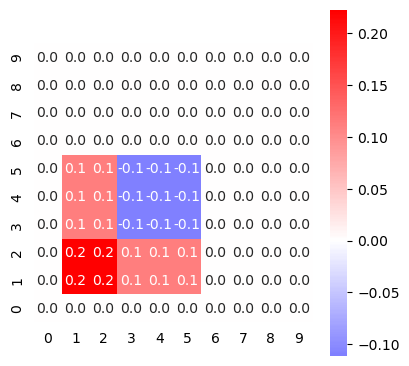

In [196]:
plt.figure(figsize=(4.5,4.5))
hm = sns.heatmap(draw_arr, center=0, 
                 square=True, annot=True, 
                 cmap='bwr', fmt=".1f")
hm.invert_yaxis()
hm.tick_params(bottom=False, left=False)

In [197]:
data = pd.DataFrame({'X':[ 1, 3, 6], 
                     'Y':[ 1, 6, 3], 
                     'Z':[10, 5, 1]})
data.index.name = 'examples'

display(data)

print("Covariance:")

display(data.cov())

,X,Y,Z
examples,,,
0,1,1,10
1,3,6,5
2,6,3,1


Covariance:


,X,Y,Z
X,6.3333,1.8333,-11.1667
Y,1.8333,6.3333,-5.1667
Z,-11.1667,-5.1667,20.3333


In [198]:
data = pd.DataFrame({'x':[ 3, 6, 3, 4], 
                     'y':[ 9, 6, 3, 0],
                     'z':[ 1, 4, 7, 0]})
data.index.name = 'examples'
display(data)
print("Covariance:")
display(data.cov()) # biased covariance, see EOC

,x,y,z
examples,,,
0,3,9,1
1,6,6,4
2,3,3,7
3,4,0,0


Covariance:


,x,y,z
x,2.0000,0.0000,0.0000
y,0.0000,15.0000,0.0000
z,0.0000,0.0000,10.0000


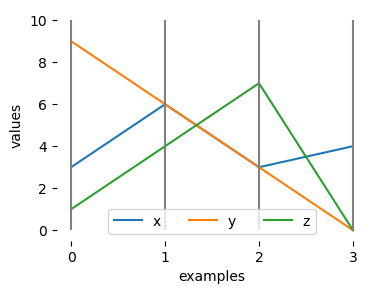

In [199]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
data.plot(ax=ax)
ax.vlines([0,1,2,3], 0, 10, colors=".5")

ax.legend(loc='lower center', ncol=3)

plt.box(False)
ax.set_xticks([0,1,2,3])
ax.set_ylabel("values");

#### Performing Discriminant Analysis

Text(0.5, 25.722222222222214, 'Predicted')

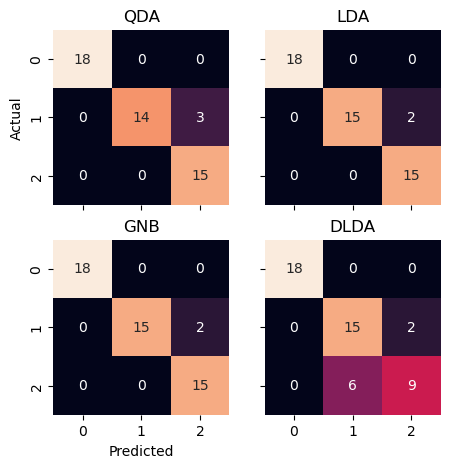

In [200]:
qda = discriminant_analysis.QuadraticDiscriminantAnalysis()
lda = discriminant_analysis.LinearDiscriminantAnalysis()
gnb = naive_bayes.GaussianNB()
dlda = DLDA()

methods = {
    "QDA":qda,
    "LDA":lda,
    "GNB":gnb,
    "DLDA":dlda
}

fig, axes = plt.subplots(2,2,figsize=(5,5),sharex = True,sharey = True)
for ax,(mod_name,model) in zip(axes.flat,methods.items()):
    preds = (model.fit(iris_train_ftrs,iris_train_tgt).predict(iris_test_ftrs))
    cm= metrics.confusion_matrix(iris_test_tgt,preds)
    sns.heatmap(cm, annot = True, cbar=False,ax=ax)
    ax.set_title(mod_name)

axes[0,0].set_ylabel('Actual')
axes[1,0].set_xlabel('Predicted')


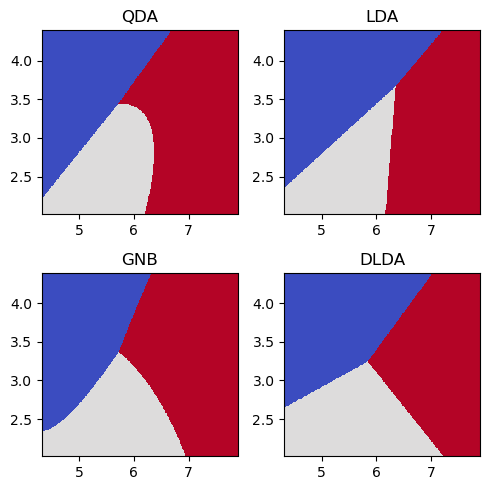

In [201]:
fig, axes = plt.subplots(2,2,figsize=(5,5))
for ax,(mod_name,model) in zip(axes.flat,methods.items()):
    plot_boundary(ax,iris.data, iris.target, model,[0,1])
    ax.set_title(mod_name)

plt.tight_layout()

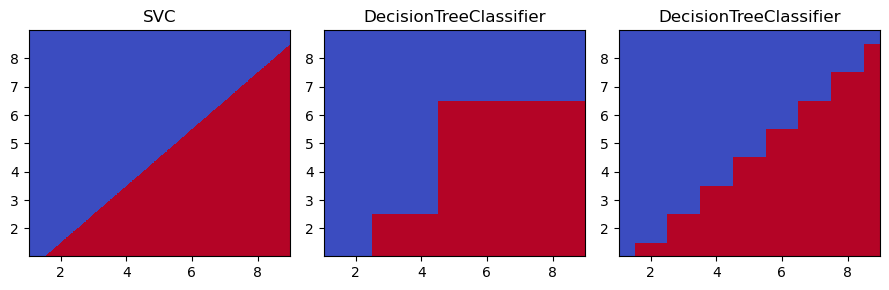

In [202]:
ftrs = np.mgrid[1:10,1:10].T.reshape(-1,2)
tgt = ftrs[:,0] > ftrs[:,1]
fig,axes = plt.subplots(1,3,figsize=(9,3))

svc = svm.SVC(kernel='linear')
dt_shallow = tree.DecisionTreeClassifier(max_depth = 3)
dt_deep = tree.DecisionTreeClassifier()
models = [svc,dt_shallow,dt_deep]

for model, ax in zip(models,axes.flat):
    plot_boundary(ax,ftrs,tgt,model,[0,1])
    ax.set_title(get_model_name(model))

plt.tight_layout()

#### Comparison of Classifiers with the digits datsets

Shape (8, 8)


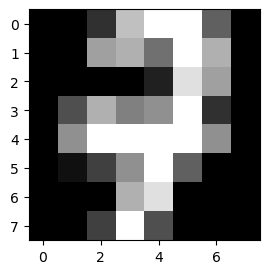

In [224]:
digits = datasets.load_digits()
print("Shape",digits.images[1].shape)
plt.figure(figsize=(3,3))
plt.imshow(digits.images[52],cmap='gray')

In [225]:
digits.target[52]

7

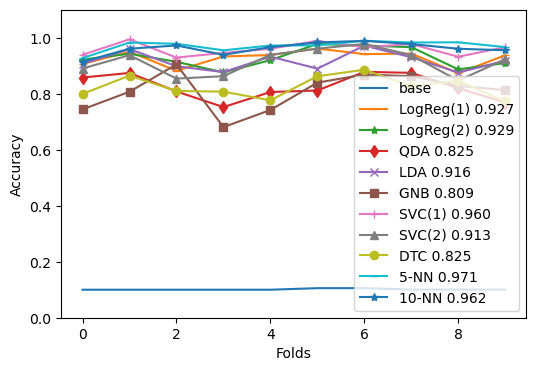

In [233]:
classifier_parade = {
    "LogReg(1)": linear_model.LogisticRegression(max_iter=1000),
    "LogReg(2)": linear_model.SGDClassifier(loss='log_loss',max_iter=1000),

    "QDA":discriminant_analysis.QuadraticDiscriminantAnalysis(),
    "LDA":discriminant_analysis.LinearDiscriminantAnalysis(),
    "GNB":naive_bayes.GaussianNB(),

    "SVC(1)":svm.SVC(kernel="linear"),
    "SVC(2)":svm.LinearSVC(),

    "DTC":tree.DecisionTreeClassifier(),
    "5-NN":neighbors.KNeighborsClassifier(n_neighbors=5),
    "10-NN":neighbors.KNeighborsClassifier(n_neighbors=10),

    

    
}

baseline = dummy.DummyClassifier(strategy='uniform')


base_score = skms.cross_val_score(baseline,digits.data,digits.target==1,cv=10,scoring='average_precision',n_jobs=-1)

fig,ax = plt.subplots(figsize=(6,4))
ax.plot(base_score,label='base')
for model_name,model in classifier_parade.items():
    cv_score = skms.cross_val_score(model,digits.data,digits.target,cv=10,scoring='f1_macro',n_jobs=-1)
    my_lbl = "{} {:.3f}".format(model_name, cv_score.mean())
    ax.plot(cv_score,label=my_lbl,marker=next(markers))

ax.set_ylim(0.0,1.1)
ax.set_xlabel('Folds')
ax.set_ylabel('Accuracy')
ax.legend(loc='lower right')
